## Droplet dynamics (Laminar to complex flow transition) - One-way droplet
### Reference: Insights into 2D Navier-Stokes Numerical Simulations, Energy-Conserving Solver Approaches

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import numpy.linalg as la
import matplotlib.animation as animation
from skimage import measure

from pathlib import Path
import json
from datetime import datetime

In [2]:
## Grid has N^2 points (2D)
## Periodic domain (D = l^d), l = length of the side of d-dimensional hypercubic domain

# Domain 
L_x = 2*np.pi
L_y = 2*np.pi
N_x = 256
N_y = 256

# 2D periodic grid
del_x = L_x/N_x
del_y = L_y/N_y
x_j = np.arange(N_x) * del_x
y_j = np.arange(N_y) * del_y
X, Y = np.meshgrid(x_j, y_j, indexing='xy')

# Wrapped wavenumber arrays
n_x = np.arange(N_x)
n_y = np.arange(N_y)
k_x = (2*np.pi/L_x) * np.where(n_x <= N_x/2, n_x, n_x - N_x)
k_y = (2*np.pi/L_y) * np.where(n_y <= N_y/2, n_y, n_y - N_y)
Kx, Ky = np.meshgrid(k_x, k_y, indexing='xy')

K2 = Kx**2 + Ky**2

dx = 2*np.pi/N_x
# diffuse interface
epsilon = 3*dx 

# Kinematic velocity/viscosity - responsible for turbulent flow
nu = 0.04
# 4.67e-3

# Friction coefficient
alpha = 0.0
# 1e-3

# Mobility in Cahn-Hilliard equation
M = 1e-5
# 6e-4

# Low sigma could break the interface
sigma = 1.0

# lamda_01 = -nu*K2 - alpha
# lamda_02 = (-3/2)*M*sigma*epsilon*K2**2 + (3/4)*(sigma/epsilon)*M*K2

# Reference for the following: Interface-induced turbulence in viscous binary fluid mixtures Supplemental Material
# Amplitude
f_0 = 0.30
# 5.0

# Wavenumber, Decreasing this causes advection, should be an integer
k_f = 2

# Forcing
f_w = f_0 * k_f * (np.cos(k_f * X) + np.cos(k_f * Y))
f_w_hat = np.fft.fft2(f_w)

T = 20.0
N_t = 10000
# delta_t = T/N_t
save_every = 100

# Single droplet parameters

xc = 0.35 * L_x
yc = 0.55 * L_y

droplet_radius = 0.10 * L_x  

coupling = False
evolve_phi = True

target_Re_values = [5, 10, 20, 40]

In [3]:
# Calculation of Reynold's number

def reynolds_number(f_0, nu, k_f):
    U = f_0 / (nu * k_f**2)
    L = 1.0 / k_f
    return U * L / nu

def nu_from_reynolds(Re, f_0, k_f):
    return np.sqrt(f_0 / (Re * k_f**3))

def make_flow_parameters(nu, f_0, k_f, alpha):

    lamda_01 = -nu * K2 - alpha
    f_w = f_0 * k_f * (np.cos(k_f * X) + np.cos(k_f * Y))
    f_w_hat = np.fft.fft2(f_w)
    Re = reynolds_number(f_0, nu, k_f)

    return lamda_01, f_w, f_w_hat, Re

sweep_table = pd.DataFrame({
    "Re_target": target_Re_values,
    "nu": [nu_from_reynolds(Re, f_0, k_f) for Re in target_Re_values],
})

print(sweep_table)

   Re_target        nu
0          5  0.086603
1         10  0.061237
2         20  0.043301
3         40  0.030619


In [4]:
experiment_name = "Experiment_DD_One_way_droplet_Re_experiment"

def create_experiment_folder(experiment_name, base_dir="Results"):
    """
    Creates:
        Results/<experiment_name>/
    """
    experiment_dir = Path(base_dir) / experiment_name
    experiment_dir.mkdir(parents=True, exist_ok=True)
    return {
        "experiment_dir": experiment_dir
    }


dirs = create_experiment_folder(experiment_name)

experiment_dir = dirs["experiment_dir"]
plots_dir = experiment_dir
animations_dir = experiment_dir

In [5]:
parameters = {

    # Experiment metadata
    "experiment_name": experiment_name,
    "created_at": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "description": "phase-field feedback term in NS is inactive",

    # Domain
    "domain": {
        "dimension": 2,
        "geometry": "periodic square domain",
        "L_x": float(L_x),
        "L_y": float(L_y),
        "N_x": int(N_x),
        "N_y": int(N_y),
        "del_x": float(del_x),
        "del_y": float(del_y),
        "dx": float(dx),
        "grid_points": int(N_x * N_y),
    },

    # Physical parameters
    "physical_parameters": {
        "epsilon": float(epsilon),
        "epsilon_definition": "epsilon = 3 * dx",
        "nu": float(nu),
        "alpha": float(alpha),
        "M": float(M),
        "sigma": float(sigma),
    },


    # Forcing
    "forcing": {
        # "type": "Kolmogorov-type forcing",
        # "reference": "Interface-induced turbulence in viscous binary fluid mixtures, Supplemental Material",
        "f_0": float(f_0),
        "k_f": k_f,
        "definition": "f_w = f_0 * k_f * (np.cos(k_f * X) + np.cos(k_f * Y))",
    },


    # Time stepping
    "time_stepping": {
        "T": float(T),
        "N_t": int(N_t),
        # "delta_t": float(delta_t),
        "save_every": int(save_every),
        "number_of_saved_snapshots": int(N_t // save_every + 1),
    },
}

def save_parameters(parameters, experiment_dir):
    json_path = experiment_dir / "parameters.json"

    # Save JSON
    with open(json_path, "w") as f:
        json.dump(parameters, f, indent=4)

    print(f"Saved parameters to:\n{json_path}")

save_parameters(parameters, experiment_dir)

Saved parameters to:
Results/Experiment_DD_One_way_droplet_Re_experiment/parameters.json


In [6]:
def single_droplet_phi(X, Y, xc, yc, R, epsilon):
    """
    Diffuse single-droplet initial condition matching the paper's convention:
        phi < 0 inside droplet
        phi > 0 in background

    Parameters
    ----------
    X, Y : 2D arrays
        Meshgrid arrays.
    xc, yc : float
        Droplet center.
    d0 : float
        Droplet diameter.
    xi : float
        Diffuse interface width parameter from the paper.
    """
    r = np.sqrt((X - xc)**2 + (Y - yc)**2)
    return np.tanh((R - r) / epsilon)

# Initialise phi - Smooth diffuse-interface droplet
# phi ≈ +1 inside droplet, phi ≈ -1 outside droplet
# phi_xy_0 = single_droplet_phi(X, Y, xc, yc, droplet_radius, epsilon)
# phi_hat = np.fft.fft2(phi_xy_0)

# Initial vorticity
# omega_xy_0 = np.zeros_like(X)
# omega_hat = np.fft.fft2(omega_xy_0)

In [7]:
# Integer Fourier mode indices for dealiasing
mx = np.fft.fftfreq(N_x) * N_x
my = np.fft.fftfreq(N_y) * N_y
MX, MY = np.meshgrid(mx, my, indexing='xy')

# 1/2-dealiasing mask for cubic nonlinearities
dealias_mask = ((np.abs(MX) < N_x//4) & (np.abs(MY) < N_y//4)).astype(float)

def dealias(hat_field):
    return hat_field * dealias_mask

# Assemble \mu using pseudo-spectral implementation

# print("initial phi stats:", phi_xy.min(), phi_xy.max(), np.mean(phi_xy))
# print("initial phi hat finite?", np.isfinite(phi_xy_hat).all())

def mu_spec(phi_hat, phi_xy):
    phi3_hat = dealias(np.fft.fft2(phi_xy**3))
    return (3/2)*sigma*epsilon*K2*phi_hat + (3/4)*(sigma/epsilon)*(phi3_hat - phi_hat)

# omega = vorticity field

def recover_velocity(omega_hat):
    psi_hat = np.zeros_like(omega_hat, dtype=complex)
    mask = (K2 != 0)
    psi_hat[mask] = omega_hat[mask] / K2[mask]

    u_x_hat = 1j * Ky * psi_hat
    u_y_hat = -1j * Kx * psi_hat

    u_x = np.fft.ifft2(u_x_hat).real
    u_y = np.fft.ifft2(u_y_hat).real

    return u_x,u_y

In [8]:
# Handling Non linear terms in CHNS equation

def advection_phi(phi_xy_hat, u_x, u_y):
    phi_x = np.fft.ifft2(1j * Kx * phi_xy_hat).real
    phi_y = np.fft.ifft2(1j * Ky * phi_xy_hat).real
    adv_xy = phi_x * u_x + phi_y * u_y
    return dealias(np.fft.fft2(adv_xy))

def advection_omega(omega_hat, u_x, u_y):
    omega_x = np.fft.ifft2(1j * Kx * omega_hat).real
    omega_y = np.fft.ifft2(1j * Ky * omega_hat).real
    adv_xy = omega_x * u_x + omega_y * u_y
    return dealias(np.fft.fft2(adv_xy))

# 2D vorticity equation
def coupling_term(phi_xy, mu_spec):
    mu_x = np.fft.ifft2(1j * Kx * mu_spec).real
    mu_y = np.fft.ifft2(1j * Ky * mu_spec).real

    term1_hat = dealias(np.fft.fft2(phi_xy * mu_y))
    term2_hat = dealias(np.fft.fft2(phi_xy * mu_x))

    return -(1j * Kx * term1_hat - 1j * Ky * term2_hat) # minus sign due to how coupling is defined in RP2

In [9]:

# Flow validation metrics


def compute_divergence(u_x, u_y):
    """
    Compute divergence of velocity field using spectral derivatives.

    div(u) = du_x/dx + du_y/dy
    """

    u_x_hat = np.fft.fft2(u_x)
    u_y_hat = np.fft.fft2(u_y)

    div_hat = 1j * Kx * u_x_hat + 1j * Ky * u_y_hat
    div_xy = np.fft.ifft2(div_hat).real

    return div_xy


def compute_divergence_errors(u_x, u_y):
    """
    Return max and L2 divergence errors.
    """

    div_xy = compute_divergence(u_x, u_y)

    max_divergence = np.max(np.abs(div_xy))
    l2_divergence = np.sqrt(np.mean(div_xy**2))

    return max_divergence, l2_divergence


def compute_kinetic_energy(u_x, u_y):
    """
    Compute kinetic energy:

        E_k = 1/2 ∫ |u|^2 dx

    On a periodic uniform grid.
    """

    kinetic_energy_density = 0.5 * (u_x**2 + u_y**2)
    kinetic_energy = np.sum(kinetic_energy_density) * del_x * del_y

    return kinetic_energy


def compute_enstrophy(omega_xy):
    """
    Compute enstrophy:

        Z = 1/2 ∫ omega^2 dx
    """

    enstrophy_density = 0.5 * omega_xy**2
    enstrophy = np.sum(enstrophy_density) * del_x * del_y

    return enstrophy


def compute_forced_mode_energy_fraction(omega_hat, k_f, tolerance=1.0e-12):
    """
    Compute the fraction of vorticity spectral energy contained in
    the forced modes.

    For forcing:
        f_w = f_0 * k_f * (cos(k_f x) + cos(k_f y))

    the directly forced modes are approximately:
        (kx, ky) = (+/- k_f, 0), (0, +/- k_f)

    This metric is useful as a transition indicator.

    Laminar regime:
        fraction close to 1

    More complex regime:
        fraction decreases as energy spreads to other modes.
    """

    spectral_energy = np.abs(omega_hat)**2

    total_energy = np.sum(spectral_energy)

    if total_energy < tolerance:
        return np.nan

    forced_mask = (
        ((np.isclose(np.abs(Kx), k_f) & np.isclose(Ky, 0.0)))
        |
        ((np.isclose(Kx, 0.0) & np.isclose(np.abs(Ky), k_f)))
    )

    forced_energy = np.sum(spectral_energy[forced_mask])

    forced_mode_fraction = forced_energy / total_energy

    return forced_mode_fraction

def compute_cfl(u_x, u_y, delta_t, del_x, del_y):
    speed = np.sqrt(u_x**2 + u_y**2)
    max_speed = np.max(speed)

    cfl_x = max_speed * delta_t / del_x
    cfl_y = max_speed * delta_t / del_y

    return max(cfl_x, cfl_y), max_speed

In [10]:

# Droplet / phase-field validation metrics


def compute_mass_phi(phi_xy):
    """
    Compute total phase-field mass:

        M_phi = ∫ phi dx

    The Cahn-Hilliard equation should conserve this quantity.
    """

    mass_phi = np.sum(phi_xy) * del_x * del_y

    return mass_phi


def compute_phase_volume(phi_xy):
    """
    Compute mass-based positive-phase volume:

        V_+ = ∫ (phi + 1)/2 dx

    For phi ≈ +1 inside the droplet and phi ≈ -1 outside,
    this estimates the amount of positive phase.

    This quantity is directly related to mass conservation.
    """

    phase_volume = np.sum((phi_xy + 1.0) / 2.0) * del_x * del_y

    return phase_volume


def compute_free_energy(phi_hat):
    """
    Compute Cahn-Hilliard free energy:

        F[phi] = ∫ [sigma/(4 epsilon) (phi^2 - 1)^2
                  + sigma epsilon/2 |grad phi|^2] dx

    This is not necessarily monotone in the one-way droplet case,
    because flow advection can stretch the interface.
    """

    phi_xy = np.fft.ifft2(phi_hat).real

    phi_x_hat = 1j * Kx * phi_hat
    phi_y_hat = 1j * Ky * phi_hat

    phi_x = np.fft.ifft2(phi_x_hat).real
    phi_y = np.fft.ifft2(phi_y_hat).real

    bulk_energy_density = (sigma / (4.0 * epsilon)) * (phi_xy**2 - 1.0)**2
    gradient_energy_density = 0.5 * sigma * epsilon * (phi_x**2 + phi_y**2)

    free_energy = np.sum(
        bulk_energy_density + gradient_energy_density
    ) * del_x * del_y

    return free_energy


def compute_mu_dissipation(mu_hat):
    """
    Compute chemical-potential dissipation:

        D_mu = M ∫ |grad mu|^2 dx

    In CH-only this should decay toward zero.
    In one-way flow it may fluctuate because advection stretches the interface.
    """

    mu_x_hat = 1j * Kx * mu_hat
    mu_y_hat = 1j * Ky * mu_hat

    mu_x = np.fft.ifft2(mu_x_hat).real
    mu_y = np.fft.ifft2(mu_y_hat).real

    dissipation = M * np.sum(mu_x**2 + mu_y**2) * del_x * del_y

    return dissipation

def compute_energy_spectrum_from_omega(omega_hat, Kx, Ky, N_x, N_y):
    K2_local = Kx**2 + Ky**2
    Kmag = np.sqrt(K2_local)

    K2_nozero = K2_local.copy()
    K2_nozero[0, 0] = 1.0

    energy_density = 0.5 * np.abs(omega_hat)**2 / K2_nozero
    energy_density /= (N_x * N_y)**2
    energy_density[0, 0] = 0.0

    k_bins = np.floor(Kmag).astype(int)
    kmax = k_bins.max()

    E_sum = np.zeros(kmax + 1)
    counts = np.zeros(kmax + 1)

    for k in range(kmax + 1):
        mask = k_bins == k
        counts[k] = np.sum(mask)

        if counts[k] > 0:
            E_sum[k] = np.sum(energy_density[mask])

    return np.arange(kmax + 1), E_sum, counts

def compute_energy_spectrum_from_velocity(u_x, u_y, KX, KY):

    N_x, N_y = u_x.shape

    u_x_hat = np.fft.fft2(u_x)
    u_y_hat = np.fft.fft2(u_y)

    E_hat = 0.5 * (
        np.abs(u_x_hat)**2 +
        np.abs(u_y_hat)**2
    ) / (N_x * N_y)**2

    K_mag = np.sqrt(KX**2 + KY**2)

    k_max = int(np.max(K_mag))

    E_shell = np.zeros(k_max + 1)

    for k in range(k_max + 1):

        mask = (K_mag >= k) & (K_mag < k + 1)

        if np.any(mask):
            E_shell[k] = np.sum(E_hat[mask])

    return np.arange(k_max + 1), E_shell

In [11]:
# Extraction of droplet geometry from phi

def polygon_area(x, y):
    """
    Shoelace formula for area of a closed polygon.
    """
    return 0.5 * np.abs(np.dot(x, np.roll(y, -1)) - np.dot(y, np.roll(x, -1)))


def polygon_perimeter(x, y, closed=True):
    """
    Perimeter of a polygonal curve.
    """
    if closed:
        dx = np.diff(np.r_[x, x[0]])
        dy = np.diff(np.r_[y, y[0]])
    else:
        dx = np.diff(x)
        dy = np.diff(y)
    return np.sum(np.sqrt(dx**2 + dy**2))


def contour_pixels_to_physical(contour_rc, dx, dy):
    """
    skimage.find_contours returns coordinates as (row, col).
    Convert to physical x,y coordinates.
    """
    r = contour_rc[:, 0]
    c = contour_rc[:, 1]
    x = c * dx
    y = r * dy
    return x, y


def effective_diameter_from_area(A):
    """
    d_p = 2 * sqrt(A / pi)
    """
    return 2.0 * np.sqrt(A / np.pi)


def reference_circle_perimeter_from_area(A):
    """
    Perimeter of a circle with the same area A.
    S0 = pi * d_p = 2 * sqrt(pi A)
    """
    return 2.0 * np.sqrt(np.pi * A)


def deformation_parameter(S, A):
    """
    Gamma = S / S0 - 1
    """
    S0 = reference_circle_perimeter_from_area(A)
    return S / S0 - 1.0


def periodic_center_of_mass(mask, Lx, Ly):
    """
    Periodic-safe center of mass of a boolean mask.
    This avoids jumps when the droplet crosses the periodic boundary.
    """
    Ny, Nx = mask.shape

    # x coordinates
    x_idx = np.arange(Nx)
    theta_x = 2.0 * np.pi * x_idx / Nx
    wx = mask.sum(axis=0).astype(float)
    if wx.sum() == 0:
        return np.nan, np.nan

    Cx = np.sum(wx * np.cos(theta_x)) / np.sum(wx)
    Sx = np.sum(wx * np.sin(theta_x)) / np.sum(wx)
    ang_x = np.arctan2(Sx, Cx) % (2.0 * np.pi)
    x_cm = Lx * ang_x / (2.0 * np.pi)

    # y coordinates
    y_idx = np.arange(Ny)
    theta_y = 2.0 * np.pi * y_idx / Ny
    wy = mask.sum(axis=1).astype(float)
    Cy = np.sum(wy * np.cos(theta_y)) / np.sum(wy)
    Sy = np.sum(wy * np.sin(theta_y)) / np.sum(wy)
    ang_y = np.arctan2(Sy, Cy) % (2.0 * np.pi)
    y_cm = Ly * ang_y / (2.0 * np.pi)

    return x_cm, y_cm


def extract_main_droplet_contour(phi_xy, level=0.0):
    """
    Extract all level-set contours and return the longest one.
    For a single-droplet setup, this is usually the main droplet boundary.
    """
    contours = measure.find_contours(phi_xy, level=level)

    if len(contours) == 0:
        return None

    # choose the longest contour in number of points
    contour = max(contours, key=lambda c: c.shape[0])
    return contour


def droplet_geometry_from_phi(phi_xy, dx, dy, Lx, Ly, level=0.0):
    """
    Compute droplet geometry from the phi=0 contour and phi<0 interior.

    Returns a dictionary with:
        area
        perimeter
        diameter
        gamma
        S0
        x_cm
        y_cm
        area_from_mask
        contour_xy
    """
    contour_rc = extract_main_droplet_contour(phi_xy, level=level)
    if contour_rc is None:
        return None

    # Contour-based geometry
    x_contour, y_contour = contour_pixels_to_physical(contour_rc, dx, dy)
    A_contour = polygon_area(x_contour, y_contour)
    S_contour = polygon_perimeter(x_contour, y_contour, closed=True)

    # Effective diameter and deformation
    d_p = effective_diameter_from_area(A_contour)
    S0 = reference_circle_perimeter_from_area(A_contour)
    Gamma = deformation_parameter(S_contour, A_contour)

    # Mask-based area and COM
    mask = (phi_xy < 0.0)
    A_mask = np.sum(mask) * dx * dy
    x_cm, y_cm = periodic_center_of_mass(mask, Lx, Ly)

    return {
        "area": A_contour,
        "perimeter": S_contour,
        "diameter": d_p,
        "gamma": Gamma,
        "S0": S0,
        "x_cm": x_cm,
        "y_cm": y_cm,
        "area_from_mask": A_mask,
        "contour_x": x_contour,
        "contour_y": y_contour,
    }


In [12]:
def initialize_droplet_tracking():
    return {
        "time": [],
        "area": [],
        "area_mask": [],
        "area_rel_error": [],
        "perimeter": [],
        "S0": [],
        "gamma": [],
        "diameter": [],
        "x_cm": [],
        "y_cm": [],
    }

# Updating function during simulation
def update_droplet_tracking(track, t, phi_xy, dx, dy, Lx, Ly, A0=None):
    geom = droplet_geometry_from_phi(phi_xy, dx, dy, Lx, Ly, level=0.0)

    if geom is None:
        return track, A0

    if A0 is None:
        A0 = geom["area"]

    rel_err = (geom["area"] - A0) / A0

    track["time"].append(t)
    track["area"].append(geom["area"])
    track["area_mask"].append(geom["area_from_mask"])
    track["area_rel_error"].append(rel_err)
    track["perimeter"].append(geom["perimeter"])
    track["S0"].append(geom["S0"])
    track["gamma"].append(geom["gamma"])
    track["diameter"].append(geom["diameter"])
    track["x_cm"].append(geom["x_cm"])
    track["y_cm"].append(geom["y_cm"])

    return track, A0

In [13]:
# # Time stepping 

# def G(omega_hat,phi_xy,mu_s,u_x,u_y):
#     if coupling:
#         return -(advection_omega(omega_hat,u_x,u_y)) + coupling_term(phi_xy,mu_s) + f_w_hat
#     else:
#         return -(advection_omega(omega_hat,u_x,u_y)) + f_w_hat

# def H(phi_xy_hat,phi_xy,u_x,u_y):
#     if evolve_phi:
#         return -(advection_phi(phi_xy_hat,u_x,u_y)) - (3/4)*(sigma/epsilon)*M*K2*dealias(np.fft.fft2(phi_xy**3))
#     else:
#         return - (3/4)*(sigma/epsilon)*M*K2*dealias(np.fft.fft2(phi_xy**3))


In [14]:

# # Initial conditions


# q_01_n = omega_hat.copy()      # vorticity Fourier coefficients
# q_02_n = phi_hat.copy()     # phase-field Fourier coefficients

# omega_history = [omega_xy_0.copy()]
# phi_history = [np.fft.ifft2(q_02_n).real.copy()]
# time_history = [0.0]

# # Droplet tracking
# track = initialize_droplet_tracking()
# A0 = None

# phi0 = np.fft.ifft2(q_02_n).real
# track, A0 = update_droplet_tracking(
#     track,
#     0.0,
#     phi0,
#     del_x,
#     del_y,
#     L_x,
#     L_y,
#     A0=A0
# )



# # ETD2 coefficients


# E_01 = np.exp(lamda_01 * delta_t)
# E_02 = np.exp(lamda_02 * delta_t)

# mask_01 = np.abs(lamda_01) > 1e-14
# mask_02 = np.abs(lamda_02) > 1e-14

# phi1_omega = np.empty_like(lamda_01, dtype=complex)
# phi1_phi = np.empty_like(lamda_02, dtype=complex)

# phi1_omega[mask_01] = (E_01[mask_01] - 1.0) / lamda_01[mask_01]
# phi1_phi[mask_02] = (E_02[mask_02] - 1.0) / lamda_02[mask_02]

# phi1_omega[~mask_01] = delta_t
# phi1_phi[~mask_02] = delta_t

# phi2_omega = np.empty_like(lamda_01, dtype=complex)
# phi2_phi = np.empty_like(lamda_02, dtype=complex)

# phi2_omega[mask_01] = (
#     E_01[mask_01]
#     - 1.0
#     - lamda_01[mask_01] * delta_t
# ) / (lamda_01[mask_01]**2 * delta_t)

# phi2_phi[mask_02] = (
#     E_02[mask_02]
#     - 1.0
#     - lamda_02[mask_02] * delta_t
# ) / (lamda_02[mask_02]**2 * delta_t)

# phi2_omega[~mask_01] = 0.5 * delta_t
# phi2_phi[~mask_02] = 0.5 * delta_t

In [15]:
def run_one_way_droplet_simulation(
    nu,
    f_0,
    k_f,
    T,
    N_t,
    save_every,
    spectrum_every=None,
    store_fields=False,
    verbose=False
):
    delta_t = T / N_t

    if spectrum_every is None:
        spectrum_every = 5 * save_every

    lamda_01, f_w, f_w_hat_local, Re = make_flow_parameters(
        nu=nu,
        f_0=f_0,
        k_f=k_f,
        alpha=alpha
    )

    lamda_02 = (
        (-3/2) * M * sigma * epsilon * K2**2
        + (3/4) * (sigma / epsilon) * M * K2
    )

    def G_local(omega_hat, u_x, u_y):
        return -advection_omega(omega_hat, u_x, u_y) + f_w_hat_local

    def H_local(phi_hat, phi_xy, u_x, u_y):
        return (
            -advection_phi(phi_hat, u_x, u_y)
            - (3/4) * (sigma / epsilon) * M * K2
            * dealias(np.fft.fft2(phi_xy**3))
        )

    # Initial conditions
    phi0 = single_droplet_phi(X, Y, xc, yc, droplet_radius, epsilon)
    omega0 = np.zeros_like(X)

    q_01_n = np.fft.fft2(omega0)
    q_02_n = np.fft.fft2(phi0)

    # Reference phase quantities
    mass_phi_initial = compute_mass_phi(phi0)
    phase_volume_initial = compute_phase_volume(phi0)

    # ETD coefficients
    E_01 = np.exp(lamda_01 * delta_t)
    E_02 = np.exp(lamda_02 * delta_t)

    mask_01 = np.abs(lamda_01) > 1e-14
    mask_02 = np.abs(lamda_02) > 1e-14

    phi1_omega = np.empty_like(lamda_01, dtype=complex)
    phi1_phi = np.empty_like(lamda_02, dtype=complex)

    phi1_omega[mask_01] = (E_01[mask_01] - 1.0) / lamda_01[mask_01]
    phi1_phi[mask_02] = (E_02[mask_02] - 1.0) / lamda_02[mask_02]

    phi1_omega[~mask_01] = delta_t
    phi1_phi[~mask_02] = delta_t

    phi2_omega = np.empty_like(lamda_01, dtype=complex)
    phi2_phi = np.empty_like(lamda_02, dtype=complex)

    phi2_omega[mask_01] = (
        E_01[mask_01]
        - 1.0
        - lamda_01[mask_01] * delta_t
    ) / (lamda_01[mask_01]**2 * delta_t)

    phi2_phi[mask_02] = (
        E_02[mask_02]
        - 1.0
        - lamda_02[mask_02] * delta_t
    ) / (lamda_02[mask_02]**2 * delta_t)

    phi2_omega[~mask_01] = 0.5 * delta_t
    phi2_phi[~mask_02] = 0.5 * delta_t

    # Histories
    metric_time_history = [0.0]

    kinetic_energy_history = []
    enstrophy_history = []
    forced_mode_fraction_history = []

    mass_phi_error_history = []
    phase_volume_error_history = []
    free_energy_history = []
    dissipation_history = []

    max_divergence_history = []
    l2_divergence_history = []

    cfl_history = []
    max_velocity_history = []

    spectrum_time_history = []
    spectrum_k_history = []
    spectrum_E_history = []

    omega_history = []
    phi_history = []
    frame_time_history = []

    track = initialize_droplet_tracking()
    A0 = None
    track, A0 = update_droplet_tracking(
        track, 0.0, phi0, del_x, del_y, L_x, L_y, A0=A0
    )

    stable = True
    stop_step = N_t

    for n in range(N_t):

        t = n * delta_t

        # Current state
        u_x_n, u_y_n = recover_velocity(q_01_n)
        phi_xy_n = np.fft.ifft2(q_02_n).real

        # One-way logic:
        # mu is not fed back into the vorticity equation.
        G_n = G_local(q_01_n, u_x_n, u_y_n)
        H_n = H_local(q_02_n, phi_xy_n, u_x_n, u_y_n)

        # Predictor
        a_01_n = q_01_n * E_01 + G_n * phi1_omega
        a_02_n = q_02_n * E_02 + H_n * phi1_phi

        a_01_n = dealias(a_01_n)
        a_02_n = dealias(a_02_n)

        a_02_n[0, 0] = q_02_n[0, 0]

        # Intermediate state
        u_x_a, u_y_a = recover_velocity(a_01_n)
        phi_xy_a = np.fft.ifft2(a_02_n).real

        G_a = G_local(a_01_n, u_x_a, u_y_a)
        H_a = H_local(a_02_n, phi_xy_a, u_x_a, u_y_a)

        # Corrector
        q_01_next = a_01_n + (G_a - G_n) * phi2_omega
        q_02_next = a_02_n + (H_a - H_n) * phi2_phi

        q_01_next = dealias(q_01_next)
        q_02_next = dealias(q_02_next)

        q_01_next[0, 0] = 0.0
        q_02_next[0, 0] = q_02_n[0, 0]

        if not np.isfinite(q_01_next).all() or not np.isfinite(q_02_next).all():
            stable = False
            stop_step = n
            break

        if n % save_every == 0:

            omega_xy_save = np.fft.ifft2(q_01_next).real
            phi_xy_save = np.fft.ifft2(q_02_next).real
            u_x_save, u_y_save = recover_velocity(q_01_next)

            mu_hat_save = mu_spec(q_02_next, phi_xy_save)

            max_divergence, l2_divergence = compute_divergence_errors(
                u_x_save,
                u_y_save
            )

            kinetic_energy = compute_kinetic_energy(
                u_x_save,
                u_y_save
            )

            enstrophy = compute_enstrophy(omega_xy_save)

            forced_mode_fraction = compute_forced_mode_energy_fraction(
                q_01_next,
                k_f
            )

            mass_phi_error = abs(
                compute_mass_phi(phi_xy_save) - mass_phi_initial
            )

            phase_volume_error = abs(
                compute_phase_volume(phi_xy_save) - phase_volume_initial
            )

            free_energy = compute_free_energy(q_02_next)
            dissipation = compute_mu_dissipation(mu_hat_save)

            cfl, max_speed = compute_cfl(
                u_x_save,
                u_y_save,
                delta_t,
                del_x,
                del_y
            )

            current_time = t + delta_t

            metric_time_history.append(current_time)

            kinetic_energy_history.append(kinetic_energy)
            enstrophy_history.append(enstrophy)
            forced_mode_fraction_history.append(forced_mode_fraction)

            mass_phi_error_history.append(mass_phi_error)
            phase_volume_error_history.append(phase_volume_error)
            free_energy_history.append(free_energy)
            dissipation_history.append(dissipation)

            max_divergence_history.append(max_divergence)
            l2_divergence_history.append(l2_divergence)

            cfl_history.append(cfl)
            max_velocity_history.append(max_speed)

            track, A0 = update_droplet_tracking(
                track,
                current_time,
                phi_xy_save,
                del_x,
                del_y,
                L_x,
                L_y,
                A0=A0
            )

            if store_fields:
                omega_history.append(omega_xy_save.copy())
                phi_history.append(phi_xy_save.copy())
                frame_time_history.append(current_time)

            if n % spectrum_every == 0:
                k_vals, E_k = compute_energy_spectrum_from_velocity(
                    u_x_save,
                    u_y_save,
                    Kx,
                    Ky,
                )

                spectrum_time_history.append(current_time)
                spectrum_k_history.append(k_vals)
                spectrum_E_history.append(E_k)

            if verbose:
                print(
                    f"Re={Re:.2f}, step={n}/{N_t}, "
                    f"KE={kinetic_energy:.3e}, "
                    f"CFL={cfl:.3e}, "
                    f"mass_err={mass_phi_error:.2e}"
                )

        q_01_n = q_01_next
        q_02_n = q_02_next

    for key in track:
        track[key] = np.asarray(track[key])

    return {
        "Re": Re,
        "nu": nu,
        "f_0": f_0,
        "k_f": k_f,
        "stable": stable,
        "stop_step": stop_step,

        "time": np.asarray(metric_time_history),

        "kinetic_energy": np.asarray(kinetic_energy_history),
        "enstrophy": np.asarray(enstrophy_history),
        "forced_mode_fraction": np.asarray(forced_mode_fraction_history),

        "mass_phi_error": np.asarray(mass_phi_error_history),
        "phase_volume_error": np.asarray(phase_volume_error_history),
        "free_energy": np.asarray(free_energy_history),
        "dissipation": np.asarray(dissipation_history),

        "max_divergence": np.asarray(max_divergence_history),
        "l2_divergence": np.asarray(l2_divergence_history),

        "cfl": np.asarray(cfl_history),
        "max_velocity": np.asarray(max_velocity_history),

        "spectrum_time": np.asarray(spectrum_time_history),
        "spectrum_k": spectrum_k_history,
        "spectrum_E": spectrum_E_history,

        "track": track,

        "omega_history": omega_history,
        "phi_history": phi_history,
        "frame_time": np.asarray(frame_time_history),
    }

In [16]:
sweep_results = []

for Re_target in target_Re_values:

    nu_sweep = nu_from_reynolds(
        Re=Re_target,
        f_0=f_0,
        k_f=k_f
    )

    result = run_one_way_droplet_simulation(
        nu=nu_sweep,
        f_0=f_0,
        k_f=k_f,
        T=T,
        N_t=N_t,
        save_every=save_every,
        spectrum_every=5 * save_every,
        store_fields=False,
        verbose=False
    )

    sweep_results.append(result)

    print(
        f"Finished Re={result['Re']:.2f}, "
        f"nu={result['nu']:.6f}, "
        f"stable={result['stable']}, "
        f"stop_step={result['stop_step']}"
    )

Finished Re=5.00, nu=0.086603, stable=True, stop_step=10000
Finished Re=10.00, nu=0.061237, stable=True, stop_step=10000
Finished Re=20.00, nu=0.043301, stable=True, stop_step=10000
Finished Re=40.00, nu=0.030619, stable=True, stop_step=10000


In [17]:
summary_rows = []

for r in sweep_results:

    gamma = r["track"]["gamma"]
    perimeter = r["track"]["perimeter"]
    area_rel_error = r["track"]["area_rel_error"]

    summary_rows.append({
        "Re": r["Re"],
        "nu": r["nu"],
        "stable": r["stable"],

        "final_KE": r["kinetic_energy"][-1] if len(r["kinetic_energy"]) else np.nan,
        "max_KE": np.nanmax(r["kinetic_energy"]) if len(r["kinetic_energy"]) else np.nan,

        "final_enstrophy": r["enstrophy"][-1] if len(r["enstrophy"]) else np.nan,
        "max_enstrophy": np.nanmax(r["enstrophy"]) if len(r["enstrophy"]) else np.nan,

        "max_CFL": np.nanmax(r["cfl"]) if len(r["cfl"]) else np.nan,
        "max_velocity": np.nanmax(r["max_velocity"]) if len(r["max_velocity"]) else np.nan,

        "max_mass_error": np.nanmax(r["mass_phi_error"]) if len(r["mass_phi_error"]) else np.nan,
        "max_phase_volume_error": np.nanmax(r["phase_volume_error"]) if len(r["phase_volume_error"]) else np.nan,

        "max_gamma": np.nanmax(gamma) if len(gamma) else np.nan,
        "final_gamma": gamma[-1] if len(gamma) else np.nan,

        "max_perimeter": np.nanmax(perimeter) if len(perimeter) else np.nan,
        "max_area_rel_error": np.nanmax(np.abs(area_rel_error)) if len(area_rel_error) else np.nan,
    })

one_way_re_sweep_summary = pd.DataFrame(summary_rows)
one_way_re_sweep_summary

,Re,nu,stable,final_KE,max_KE,final_enstrophy,max_enstrophy,max_CFL,max_velocity,max_mass_error,max_phase_volume_error,max_gamma,final_gamma,max_perimeter,max_area_rel_error
0,5.0,0.086603,True,14.773354,14.773354,59.093415,59.093415,0.099696,1.223460,7.105427e-15,1.110223e-15,3.578643,1.770583,12.467857,0.999506
1,10.0,0.061237,True,29.147270,29.147270,116.589081,116.589081,0.140036,1.718498,7.105427e-15,1.110223e-15,3.662768,2.120365,13.087511,0.999751
2,20.0,0.043301,True,55.443269,55.443269,221.773075,221.773075,0.193137,2.370143,7.105427e-15,1.110223e-15,3.984959,0.529655,13.618569,0.998277
3,40.0,0.030619,True,98.409132,98.409132,393.636529,393.636529,0.257311,3.157678,7.105427e-15,1.110223e-15,3.924534,1.670205,13.858453,0.998640


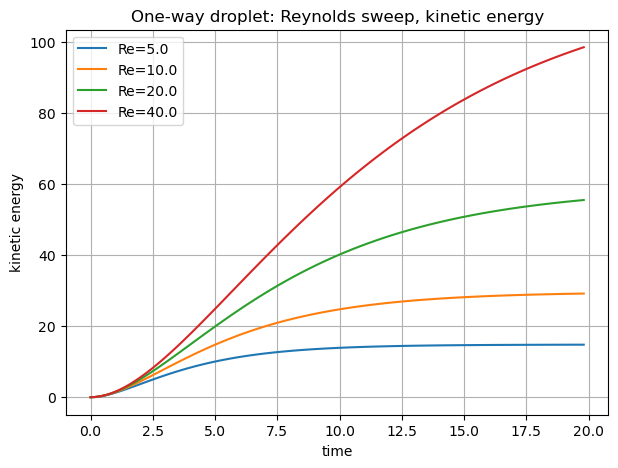

In [18]:
plt.figure(figsize=(7, 5))

for r in sweep_results:
    n = min(len(r["time"]) - 1, len(r["kinetic_energy"]))
    plt.plot(
        r["time"][1:n+1],
        r["kinetic_energy"][:n],
        label=f"Re={r['Re']:.1f}"
    )

plt.xlabel("time")
plt.ylabel("kinetic energy")
plt.title("One-way droplet: Reynolds sweep, kinetic energy")
plt.grid(True)
plt.legend()
plt.show()

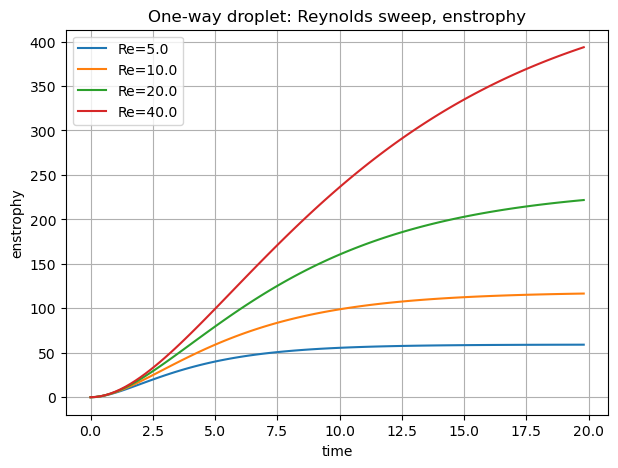

In [19]:
plt.figure(figsize=(7, 5))

for r in sweep_results:
    n = min(len(r["time"]) - 1, len(r["enstrophy"]))
    plt.plot(
        r["time"][1:n+1],
        r["enstrophy"][:n],
        label=f"Re={r['Re']:.1f}"
    )

plt.xlabel("time")
plt.ylabel("enstrophy")
plt.title("One-way droplet: Reynolds sweep, enstrophy")
plt.grid(True)
plt.legend()
plt.show()

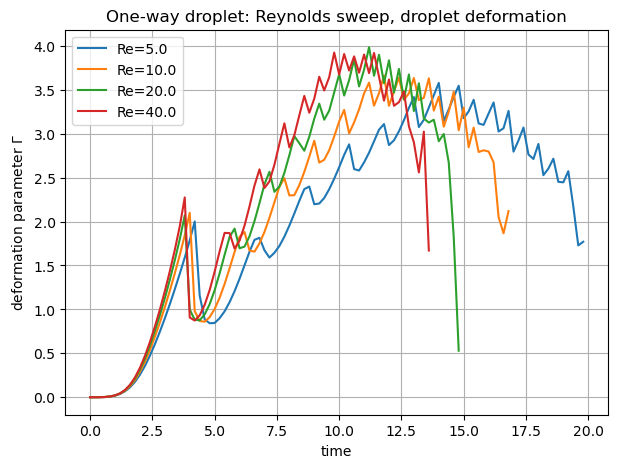

In [20]:
plt.figure(figsize=(7, 5))

for r in sweep_results:
    plt.plot(
        r["track"]["time"],
        r["track"]["gamma"],
        label=f"Re={r['Re']:.1f}"
    )

plt.xlabel("time")
plt.ylabel(r"deformation parameter $\Gamma$")
plt.title("One-way droplet: Reynolds sweep, droplet deformation")
plt.grid(True)
plt.legend()
plt.show()

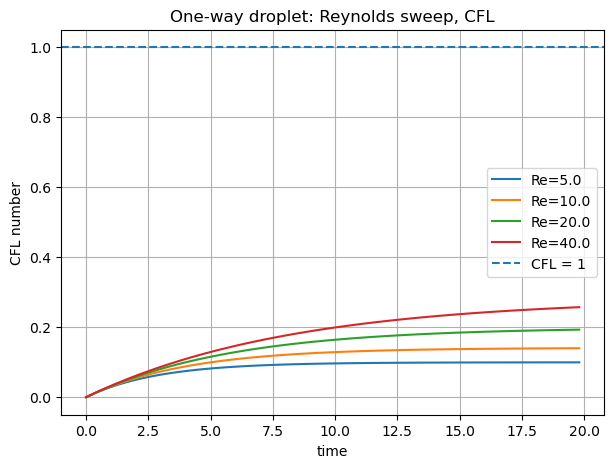

In [21]:
plt.figure(figsize=(7, 5))

for r in sweep_results:
    n = min(len(r["time"]) - 1, len(r["cfl"]))
    plt.plot(
        r["time"][1:n+1],
        r["cfl"][:n],
        label=f"Re={r['Re']:.1f}"
    )

plt.axhline(1.0, linestyle="--", label="CFL = 1")
plt.xlabel("time")
plt.ylabel("CFL number")
plt.title("One-way droplet: Reynolds sweep, CFL")
plt.grid(True)
plt.legend()
plt.show()

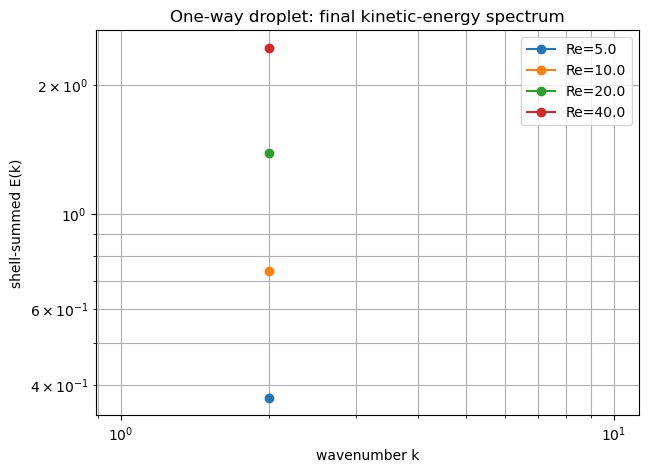

In [22]:
plt.figure(figsize=(7, 5))

for r in sweep_results:
    if len(r["spectrum_E"]) > 0:
        k = r["spectrum_k"][-1]
        E = r["spectrum_E"][-1]

        mask = (k > 0) & (E > 1e-16)

        plt.loglog(
            k[mask],
            E[mask],
            marker="o",
            label=f"Re={r['Re']:.1f}"
        )

plt.xlabel("wavenumber k")
plt.ylabel("shell-summed E(k)")
plt.title("One-way droplet: final kinetic-energy spectrum")
plt.grid(True, which="both")
plt.legend()
plt.show()

In [41]:
for r in sweep_results:
    k = r["spectrum_k"][-1]
    E = r["spectrum_E"][-1]

    total_E = np.sum(E)
    dominant_index = np.argmax(E)
    dominant_k = k[dominant_index]
    dominant_fraction = E[dominant_index] / total_E

    print(
        f"Re={r['Re']:.1f}, "
        f"dominant k={dominant_k}, "
        f"dominant fraction={dominant_fraction:.6f}"
    )

Re=5.0, dominant k=2, dominant fraction=1.000000
Re=10.0, dominant k=2, dominant fraction=1.000000
Re=20.0, dominant k=2, dominant fraction=1.000000
Re=40.0, dominant k=2, dominant fraction=1.000000


In [42]:
domain_area = L_x * L_y

for r in sweep_results:
    spectrum_total = np.sum(r["spectrum_E"][-1]) * domain_area
    ke_final = r["kinetic_energy"][-1]

    print(
        f"Re={r['Re']:.1f}, "
        f"KE final={ke_final:.6e}, "
        f"spectrum integral={spectrum_total:.6e}, "
        f"relative error={abs(spectrum_total - ke_final)/ke_final:.3e}"
    )

Re=5.0, KE final=1.477335e+01, spectrum integral=1.476344e+01, relative error=6.708e-04
Re=10.0, KE final=2.914727e+01, spectrum integral=2.904783e+01, relative error=3.412e-03
Re=20.0, KE final=5.544327e+01, spectrum integral=5.489292e+01, relative error=9.926e-03
Re=40.0, KE final=9.840913e+01, spectrum integral=9.645285e+01, relative error=1.988e-02
